# Gradient Boosting y LightGBM
El gradient boosting (Friedman, 2001) también combina muchos árboles, pero de forma secuencial. Cada árbol nuevo se entrena para corregir los errores que cometen los árboles anteriores. Suele alcanzar mayor precisión que Random Forest, a cambio de requerir un ajuste de hiperparámetros más cuidadoso.

Entre las implementaciones disponibles (XGBoost, LightGBM, CatBoost) se ha elegido LightGBM (Ke et al., 2017). Admite variables categóricas de forma nativa, sin necesidad de codificación one-hot, y es rápido de entrenar.


1. Instalar LightGBM                              
2. Cargar datos y variables    
3. Preparar las variables para LightGBM
4. Ajuste de hiperparámetros y entrenamiento ratio - (L2)
5. Ajuste de hiperparámetros y entrenamiento log(ratio) - (L2)
6. Ajuste de hiperparámetros y entrenamiento ratio - (L1)
7. Resultados por fold y guardar predicciones

Funcion de pérdidas: L2 (RMSE) y L1 (MAE)

## 1. Instalar LightGBM   

In [23]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [24]:
import lightgbm
from lightgbm import LGBMRegressor
print(lightgbm.__version__)

4.7.0


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn 
import pyarrow as pa
from itertools import product

from funciones_modelado import metricas, obtener_fold

## 2. Cargar datos y variables    

In [26]:
df = pd.read_parquet("datos/df_split.parquet")
folds = pd.read_csv("datos/folds.csv", dtype=str)
display(df.sample(1))

,fecha_fase,IDMOTask,smOrdenId,TipoFase,CodigoMaquina,Familia Maquinas,Línea Producto,Família Producto,Quantity,TiempoPrevisto,ratio,inicio_orden,mes_orden,split,maquina_no_vista
13512,2025-10-01 16:38:37.763,9d26bb48-7952-4546-8616-4b20f8b82b27,OF2508902,CH8,CM05,CH,B,BX,1.0,139.0,0.848621,2025-09-24 22:04:32.247,2025-09,desarrollo,False


In [27]:
MESES_VALIDACION = folds["mes_validacion"].tolist()

df["Línea Producto"]   = df["Línea Producto"].fillna("Desconocida")
df["Família Producto"] = df["Família Producto"].fillna("Desconocida")

VARIABLES_CATEGORICAS = ["CodigoMaquina", "Familia Maquinas", "TipoFase",
                         "Línea Producto", "Família Producto"]
VARIABLES_NUMERICAS   = ["TiempoPrevisto", "Quantity"]
OBJETIVO              = "ratio"

## 3. Preparar las variables para LightGBM

LightGBM puede trabajar con categorias sin orden, eso es beneficioso teniendo en cuenta que Random Forest cortaba en base a grupos contiguos.

In [28]:
df[VARIABLES_CATEGORICAS] = df[VARIABLES_CATEGORICAS].astype("category")

In [29]:
X_COLS = VARIABLES_CATEGORICAS + VARIABLES_NUMERICAS

In [30]:
NE = []
NL = []
MCS = []

modelo_LGBM = LGBMRegressor(
                n_estimators=NE, 
                learning_rate=0.05, 
                num_leaves=NL,
                min_child_samples = MCS,
                random_state=42
                )

## 4. Ajuste de hiperparámetros y entrenamiento ratio

4.1 Evaluar la mejor combinación entre:
- `num_leaves` (**NL**)
- `min_child_samples` (**MCS**)

In [31]:
NL  = [15, 30, 45, 60]
MCS = [10, 20, 35, 50]

modelo_LGBM = LGBMRegressor(n_estimators=500, learning_rate=0.05,
                            random_state=42, verbose=-1)

filas = []
for nl, mcs in product(NL, MCS):
    modelo_LGBM.set_params(num_leaves=nl, min_child_samples=mcs)

    maes, rmses, maes_train = [], [], []
    for mes in MESES_VALIDACION:
        train, valid = obtener_fold(df, mes)
        modelo_LGBM.fit(train[X_COLS], train[OBJETIVO])            # APRENDER
        pred = modelo_LGBM.predict(valid[X_COLS])                  # PREDECIR

        m = metricas(valid[OBJETIVO], pred)
        maes.append(m["MAE"])
        rmses.append(m["RMSE"])
        maes_train.append(metricas(train[OBJETIVO], modelo_LGBM.predict(train[X_COLS]))["MAE"])

    filas.append({"num_leaves": nl, "min_child_samples": mcs,
                  "MAE_train": np.mean(maes_train),
                  "MAE_medio_val": np.mean(maes),
                  "RMSE_medio": np.mean(rmses),
                  "MAE_por_fold": np.round(maes, 3)})

ajuste_LGBM = pd.DataFrame(filas).round(3).sort_values("MAE_medio_val")
display(ajuste_LGBM)

,num_leaves,min_child_samples,MAE_train,MAE_medio_val,RMSE_medio,MAE_por_fold
0,15,10,0.794,0.847,1.224,"[0.901, 0.813, 0.828]"
1,15,20,0.798,0.849,1.225,"[0.906, 0.812, 0.83]"
2,15,35,0.803,0.849,1.225,"[0.908, 0.811, 0.828]"
3,15,50,0.806,0.850,1.228,"[0.91, 0.813, 0.828]"
6,30,35,0.783,0.852,1.232,"[0.909, 0.813, 0.835]"
4,30,10,0.767,0.853,1.231,"[0.904, 0.815, 0.839]"
5,30,20,0.775,0.853,1.231,"[0.911, 0.815, 0.835]"
7,30,50,0.788,0.855,1.234,"[0.91, 0.818, 0.838]"
9,45,20,0.763,0.856,1.234,"[0.908, 0.816, 0.843]"
8,45,10,0.752,0.858,1.237,"[0.912, 0.819, 0.843]"


`num_leaves` es el hiperparámetro que más influye: cuantas menos hojas, menor error en validación. Al aumentar las hojas, el error en entrenamiento baja y el de validación sube, lo que indica sobreajuste. `min_child_samples` apenas influye (3 milésimas como mucho).

La mejor combinación es num_leaves = 15 y min_child_samples = 10. Como 15 es el menor valor probado, se amplía la búsqueda hacia valores más bajos.

In [32]:
NL  = [4, 7, 10, 15]
MCS = [10]

modelo_LGBM_2 = LGBMRegressor(n_estimators=500, learning_rate=0.05,
                            random_state=42, verbose=-1)

filas = []
for nl, mcs in product(NL, MCS):
    modelo_LGBM_2.set_params(num_leaves=nl, min_child_samples=mcs)

    maes, rmses, maes_train = [], [], []
    for mes in MESES_VALIDACION:
        train, valid = obtener_fold(df, mes)
        modelo_LGBM_2.fit(train[X_COLS], train[OBJETIVO])            # APRENDER
        pred = modelo_LGBM_2.predict(valid[X_COLS])                  # PREDECIR

        m = metricas(valid[OBJETIVO], pred)
        maes.append(m["MAE"])
        rmses.append(m["RMSE"])
        maes_train.append(metricas(train[OBJETIVO], modelo_LGBM_2.predict(train[X_COLS]))["MAE"])

    filas.append({"num_leaves": nl, "min_child_samples": mcs,
                  "MAE_train": np.mean(maes_train),
                  "MAE_medio_val": np.mean(maes),
                  "RMSE_medio": np.mean(rmses),
                  "MAE_por_fold": np.round(maes, 3)})

ajuste_LGBM_2 = pd.DataFrame(filas).round(3).sort_values("MAE_medio_val")
display(ajuste_LGBM_2)

,num_leaves,min_child_samples,MAE_train,MAE_medio_val,RMSE_medio,MAE_por_fold
3,15,10,0.794,0.847,1.224,"[0.901, 0.813, 0.828]"
2,10,10,0.809,0.849,1.225,"[0.907, 0.811, 0.828]"
1,7,10,0.821,0.851,1.226,"[0.91, 0.817, 0.826]"
0,4,10,0.841,0.856,1.230,"[0.917, 0.82, 0.829]"


La ampliación hacia valores más bajos confirma el óptimo. Por debajo de 15 hojas el error en validación vuelve a subir. Con menos hojas el modelo se vuelve demasiado simple. Se adopta **num_leaves = 15 y min_child_samples = 10** (MAE 0,847).

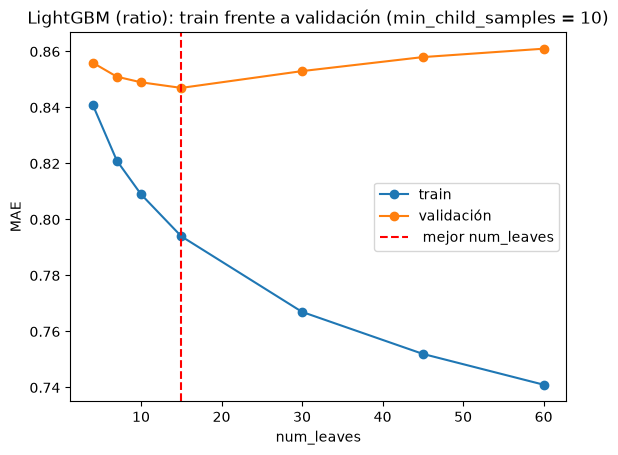

In [33]:
todo = pd.concat([ajuste_LGBM, ajuste_LGBM_2]).drop_duplicates(["num_leaves", "min_child_samples"])
linea = todo[todo["min_child_samples"] == 10].sort_values("num_leaves")

plt.plot(linea["num_leaves"], linea["MAE_train"], marker="o", label="train")
plt.plot(linea["num_leaves"], linea["MAE_medio_val"], marker="o", label="validación")
plt.xlabel("num_leaves")
plt.ylabel("MAE")
plt.title("LightGBM (ratio): train frente a validación (min_child_samples = 10)")
plt.axvline(x=15, color="red", linestyle="--", linewidth=1.5, label=" mejor num_leaves")
plt.legend()
plt.show()

4.2 Evaluar la mejor combinación de:
- `n_estimators` (**NL**) con `num_leaves = 15` y `min_child_samples = 10` fijos. 

In [34]:
NE = [250, 500, 750, 1000]

modelo_LGBM.set_params(num_leaves=15, min_child_samples=10)

filas = []
for ne in NE:
    modelo_LGBM.set_params(n_estimators=ne)

    maes, rmses, maes_train = [], [], []
    for mes in MESES_VALIDACION:
        train, valid = obtener_fold(df, mes)
        modelo_LGBM.fit(train[X_COLS], train[OBJETIVO])            # APRENDER
        pred = modelo_LGBM.predict(valid[X_COLS])                  # PREDECIR

        m = metricas(valid[OBJETIVO], pred)
        maes.append(m["MAE"])
        rmses.append(m["RMSE"])
        maes_train.append(metricas(train[OBJETIVO], modelo_LGBM.predict(train[X_COLS]))["MAE"])

    filas.append({"n_estimators": ne,
                  "MAE_train": np.mean(maes_train),
                  "MAE_medio_val": np.mean(maes),
                  "RMSE_medio": np.mean(rmses),
                  "MAE_por_fold": np.round(maes, 3)})

ajuste_lgbm_ne = pd.DataFrame(filas).round(3)
print(ajuste_lgbm_ne)

   n_estimators  MAE_train  MAE_medio_val  RMSE_medio           MAE_por_fold
0           250      0.814          0.849       1.224  [0.907, 0.813, 0.826]
1           500      0.794          0.847       1.224  [0.901, 0.813, 0.828]
2           750      0.782          0.848       1.226  [0.901, 0.812, 0.831]
3          1000      0.772          0.850       1.229  [0.901, 0.813, 0.836]


Con `num_leaves = 15` y `min_child_samples = 10` fijos, el número de árboles apenas influye: el MAE en validación se mueve entre 0,847 y 0,850. El error en entrenamiento baja al añadir árboles, pero el de validación deja de mejorar a partir de 500. Se adopta **`n_estimators = 500`** (MAE 0,847).

Configuración final (ratio): `num_leaves = 15`, `min_child_samples = 10`, `n_estimators = 500`, `learning_rate = 0,05`.

## 5. Ajuste de hiperparámetros y entrenamiento log(ratio)

In [35]:
NL  = [4, 7, 10, 15, 30, 45, 60]
MCS = [10, 20, 35, 50]

modelo_LGBM_log = LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                random_state=42, verbose=-1)

filas = []
for nl, mcs in product(NL, MCS):
    modelo_LGBM_log.set_params(num_leaves=nl, min_child_samples=mcs)

    maes, rmses, maes_train = [], [], []
    for mes in MESES_VALIDACION:
        train, valid = obtener_fold(df, mes)
        modelo_LGBM_log.fit(train[X_COLS], np.log(train[OBJETIVO]))           # APRENDER con log(ratio)
        pred = np.exp(modelo_LGBM_log.predict(valid[X_COLS]))                 # PREDECIR y volver a ratio

        m = metricas(valid[OBJETIVO], pred)
        maes.append(m["MAE"])
        rmses.append(m["RMSE"])
        pred_train = np.exp(modelo_LGBM_log.predict(train[X_COLS]))           # train en escala ratio
        maes_train.append(metricas(train[OBJETIVO], pred_train)["MAE"])

    filas.append({"num_leaves": nl, "min_child_samples": mcs,
                  "MAE_train": np.mean(maes_train),
                  "MAE_medio_val": np.mean(maes),
                  "RMSE_medio": np.mean(rmses),
                  "MAE_por_fold": np.round(maes, 3)})

ajuste_lgbm_log = pd.DataFrame(filas).round(3).sort_values("MAE_medio_val")
display(ajuste_lgbm_log)

,num_leaves,min_child_samples,MAE_train,MAE_medio_val,RMSE_medio,MAE_por_fold
12,15,10,0.761,0.835,1.296,"[0.895, 0.797, 0.812]"
8,10,10,0.774,0.837,1.298,"[0.899, 0.8, 0.811]"
13,15,20,0.764,0.837,1.298,"[0.898, 0.797, 0.815]"
7,7,50,0.789,0.838,1.300,"[0.899, 0.803, 0.812]"
9,10,20,0.776,0.838,1.299,"[0.899, 0.801, 0.814]"
15,15,50,0.770,0.838,1.299,"[0.899, 0.801, 0.815]"
11,10,50,0.780,0.838,1.300,"[0.901, 0.801, 0.814]"
6,7,35,0.788,0.839,1.301,"[0.9, 0.804, 0.812]"
10,10,35,0.778,0.839,1.301,"[0.9, 0.801, 0.816]"
14,15,35,0.768,0.839,1.300,"[0.9, 0.803, 0.816]"


Se ha explorado directamente todo el rango (num_leaves de 4 a 60, min_child_samples de 10 a 50). El error en validación tiene forma de U respecto a num_leaves, con el mínimo en 15 hojas. Con más hojas aparece sobreajuste y con menos el modelo se queda corto. min_child_samples apenas influye (3–4 milésimas).

Se adopta **num_leaves = 15 y min_child_samples = 10** (MAE 0,835), la misma combinación que en la versión ratio.

In [36]:
NE = [250, 500, 750, 1000]

modelo_LGBM_log.set_params(num_leaves=15, min_child_samples=10)

filas = []
for ne in NE:
    modelo_LGBM_log.set_params(n_estimators=ne)

    maes, rmses, maes_train = [], [], []
    for mes in MESES_VALIDACION:
        train, valid = obtener_fold(df, mes)
        modelo_LGBM_log.fit(train[X_COLS], np.log(train[OBJETIVO]))            # APRENDER
        pred = np.exp(modelo_LGBM_log.predict(valid[X_COLS]))                  # PREDECIR

        m = metricas(valid[OBJETIVO], pred)
        maes.append(m["MAE"])
        rmses.append(m["RMSE"])
        pred_train = np.exp(modelo_LGBM_log.predict(train[X_COLS]))
        maes_train.append(metricas(train[OBJETIVO], pred_train)["MAE"])

    filas.append({"n_estimators": ne,
                  "MAE_train": np.mean(maes_train),
                  "MAE_medio_val": np.mean(maes),
                  "RMSE_medio": np.mean(rmses),
                  "MAE_por_fold": np.round(maes, 3)})

ajuste_lgbm_log_ne = pd.DataFrame(filas).round(3)
display(ajuste_lgbm_log_ne)

,n_estimators,MAE_train,MAE_medio_val,RMSE_medio,MAE_por_fold
0,250,0.779,0.837,1.299,"[0.9, 0.799, 0.811]"
1,500,0.761,0.835,1.296,"[0.895, 0.797, 0.812]"
2,750,0.749,0.837,1.297,"[0.898, 0.797, 0.817]"
3,1000,0.740,0.839,1.299,"[0.898, 0.797, 0.821]"


Con `num_leaves = 15` y `min_child_samples = 10` fijos, el número de árboles apenas influye: el MAE en validación se mueve entre 0,835 y 0,839. El error en entrenamiento baja al añadir árboles (0,779 → 0,740) y se aleja del de validación, lo que indica que el modelo empieza a memorizar. Se adopta **n_estimators = 500** (MAE 0,835).

La configuración final (log(ratio)): num_leaves = 15, min_child_samples = 10, n_estimators = 500, learning_rate = 0,05. Es la misma configuración que en la versión ratio, así que la única diferencia entre ambas es la variable objetivo.

## 6. Ajuste de hiperparámetros y entrenamiento ratio - (L1)

Hasta ahora todos los modelos se han entrenado con la función de pérdida por defecto, L2 (error al cuadrado), que lleva la predicción hacia la media. Sin embargo, la métrica más interesante para este proyecto es el MAE, que premia acertar la mediana.

Ahora se prueba la función de pérdida L1, que minimiza el error absoluto: todos los errores pesan igual, sin penalizar más los grandes. Con L1 la predicción apunta a la mediana.

Será interesante compararlo con log(ratio), ya que a efectos prácticos ambas opciones buscan lo mismo: acercar la predicción a la fase típica. L1 lo hace de forma directa y log(ratio), de forma indirecta.

In [37]:
modelo_LGBM_l1 = LGBMRegressor(
    objective="l1",                  # L1 - MAE - apunta a la mediana
    n_estimators=500,
    learning_rate=0.05,
    min_child_samples=10,
    random_state=42,
    verbose=-1,
)

NL = [7, 15, 30, 60] # Por lo experimentado hasta ahora es donde realmente hay variabilidad

filas = []
for nl in NL:
    modelo_LGBM_l1.set_params(num_leaves=nl)

    maes, rmses, maes_train = [], [], []
    for mes in MESES_VALIDACION:
        train, valid = obtener_fold(df, mes)
        modelo_LGBM_l1.fit(train[X_COLS], train[OBJETIVO])        
        pred = modelo_LGBM_l1.predict(valid[X_COLS])

        m = metricas(valid[OBJETIVO], pred)
        maes.append(m["MAE"])
        rmses.append(m["RMSE"])
        maes_train.append(metricas(train[OBJETIVO], modelo_LGBM_l1.predict(train[X_COLS]))["MAE"])

    filas.append({"num_leaves": nl,
                  "MAE_train": np.mean(maes_train),
                  "MAE_medio_val": np.mean(maes),
                  "RMSE_medio": np.mean(rmses),
                  "MAE_por_fold": np.round(maes, 3)})

ajuste_lgbm_l1 = pd.DataFrame(filas).round(3)
display(ajuste_lgbm_l1)

,num_leaves,MAE_train,MAE_medio_val,RMSE_medio,MAE_por_fold
0,7,0.789,0.851,1.329,"[0.919, 0.81, 0.823]"
1,15,0.767,0.850,1.325,"[0.917, 0.81, 0.822]"
2,30,0.744,0.850,1.323,"[0.921, 0.805, 0.824]"
3,60,0.723,0.851,1.324,"[0.919, 0.806, 0.828]"


Se ha probado LightGBM optimizando directamente el error absoluto (L1) sobre el ratio, manteniendo la configuración ajustada. El MAE en validación apenas varía con num_leaves.

L1 no mejora a las versiones L2: su MAE es peor que el de L2 con log(ratio) (0,835) y que el de L2 con ratio (0,847), y su RMSE es el más alto de las tres (1,325). El resultado se repite en los 3 folds.

La ventaja de log(ratio) en MAE no se explica solo porque su predicción se acerque a la mediana: optimizar directamente la mediana con L1 da un resultado peor. Se mantiene L2 con log(ratio) como mejor versión de LightGBM.

## 7. Resultados por fold y guardar predicciones

Resultado del modelo final:

In [38]:
CONFIG_FINAL = dict(num_leaves=15, min_child_samples=10, n_estimators=500, learning_rate=0.05)
modelo_LGBM.set_params(**CONFIG_FINAL)
modelo_LGBM_log.set_params(**CONFIG_FINAL)

filas_ratio, filas_log, partes = [], [], []
for mes in MESES_VALIDACION:
    train, valid = obtener_fold(df, mes)

    # Versión ratio
    modelo_LGBM.fit(train[X_COLS], train[OBJETIVO])
    pred_ratio = modelo_LGBM.predict(valid[X_COLS])

    # Versión log(ratio)
    modelo_LGBM_log.fit(train[X_COLS], np.log(train[OBJETIVO]))
    pred_log = np.exp(modelo_LGBM_log.predict(valid[X_COLS]))

    filas_ratio.append({"bloque": f"valid {mes}", "n_train": len(train),
                        **metricas(valid[OBJETIVO], pred_ratio)})
    filas_log.append({"bloque": f"valid {mes}", "n_train": len(train),
                      **metricas(valid[OBJETIVO], pred_log)})

    partes.append(pd.DataFrame({
        "IDMOTask":        valid["IDMOTask"].values,
        "mes_orden":       valid["mes_orden"].values,
        "ratio":           valid[OBJETIVO].values,
        "pred_lgbm_ratio": pred_ratio,
        "pred_lgbm_log":   pred_log,
    }))

resultados_lgbm     = pd.DataFrame(filas_ratio).round(3)
resultados_lgbm_log = pd.DataFrame(filas_log).round(3)
pred_lgbm_valid     = pd.concat(partes, ignore_index=True)

display("LightGBM ratio:", resultados_lgbm)
display("LightGBM log(ratio):", resultados_lgbm_log)

pred_lgbm_valid.to_parquet("predicciones/lgbm_valid.parquet", index=False)

'LightGBM ratio:'

,bloque,n_train,MAE,RMSE,n
0,valid 2026-02,8940,0.901,1.294,919
1,valid 2026-03,9859,0.813,1.181,997
2,valid 2026-04,10856,0.828,1.197,971


'LightGBM log(ratio):'

,bloque,n_train,MAE,RMSE,n
0,valid 2026-02,8940,0.895,1.369,919
1,valid 2026-03,9859,0.797,1.247,997
2,valid 2026-04,10856,0.812,1.270,971


Con la configuración final (num_leaves = 15, min_child_samples = 10, n_estimators = 500, learning_rate = 0,05) en ambas versiones, log(ratio) obtiene menor MAE en los 3 folds. En RMSE ocurre lo contrario: la versión ratio es mejor en los 3 folds.

Es el mismo comportamiento observado en Ridge y en Random Forest. La versión log reduce el error en la fase típica, pero comete más error en las fases con desviaciones grandes. Como el MAE es la métrica principal, se considera log(ratio) la mejor versión de LightGBM.

Las predicciones de validación de ambas versiones se guardan en `lgbm_valid.parquet` para la evaluación final.

---

> Todo lo que se ejecute a partir de aqui es fruto tras haber realizado la comparación de los 3 modelos en Evaluación en el notebook `10.5_VALIDACIÓN`.

## Test

In [39]:
# Test: reentrenar con todo desarrollo y predecir test (hiperparámetros congelados de validación)
desarrollo = df[df["split"] == "desarrollo"]
test       = df[df["split"] == "test"]

# Versión ratio
modelo_LGBM.fit(desarrollo[X_COLS], desarrollo[OBJETIVO])
pred_ratio_test = modelo_LGBM.predict(test[X_COLS])

# Versión log(ratio)
modelo_LGBM_log.fit(desarrollo[X_COLS], np.log(desarrollo[OBJETIVO]))
pred_log_test = np.exp(modelo_LGBM_log.predict(test[X_COLS]))

pred_lgbm_test = pd.DataFrame({
    "IDMOTask":        test["IDMOTask"].values,
    "mes_orden":       test["mes_orden"].values,
    "ratio":           test[OBJETIVO].values,
    "pred_lgbm_ratio": pred_ratio_test,
    "pred_lgbm_log":   pred_log_test,
})

print(pred_lgbm_test.shape, pred_lgbm_test.isna().sum().sum())
# guardo en un parquet distinto al de validación
pred_lgbm_test.to_parquet("predicciones/lgbm_test.parquet", index=False) 

(2396, 5) 0


Una vez estudiado los Test en el notebook `10.5_VALIDACIÓN` prentendo hacer un estudio de este modelo para revisar su overfiting o undefiting. 

In [40]:
# Sobreajuste: MAE en train vs MAE en datos no vistos (LightGBM-log)
filas = []
for bloque in MESES_VALIDACION + ["test"]:
    if bloque == "test":
        train = df[df["split"] == "desarrollo"]
        evalu = df[df["split"] == "test"]
    else:
        train, evalu = obtener_fold(df, bloque)

    modelo_LGBM_log.fit(train[X_COLS], np.log(train[OBJETIVO]))

    pred_train = np.exp(modelo_LGBM_log.predict(train[X_COLS]))
    pred_eval  = np.exp(modelo_LGBM_log.predict(evalu[X_COLS]))

    mae_train = metricas(train[OBJETIVO], pred_train)["MAE"]
    mae_eval  = metricas(evalu[OBJETIVO], pred_eval)["MAE"]

    filas.append({"bloque": bloque if bloque not in MESES_VALIDACION else f"k {bloque}", 
                  "n_train": len(train),
                  "MAE_train": mae_train, 
                  "MAE_eval": mae_eval,
                  "diferencia": mae_eval - mae_train})

sobreajuste = pd.DataFrame(filas)
display(sobreajuste.round(3))

,bloque,n_train,MAE_train,MAE_eval,diferencia
0,k 2026-02,8940,0.754,0.895,0.141
1,k 2026-03,9859,0.764,0.797,0.032
2,k 2026-04,10856,0.765,0.812,0.047
3,test,11827,0.768,0.785,0.018


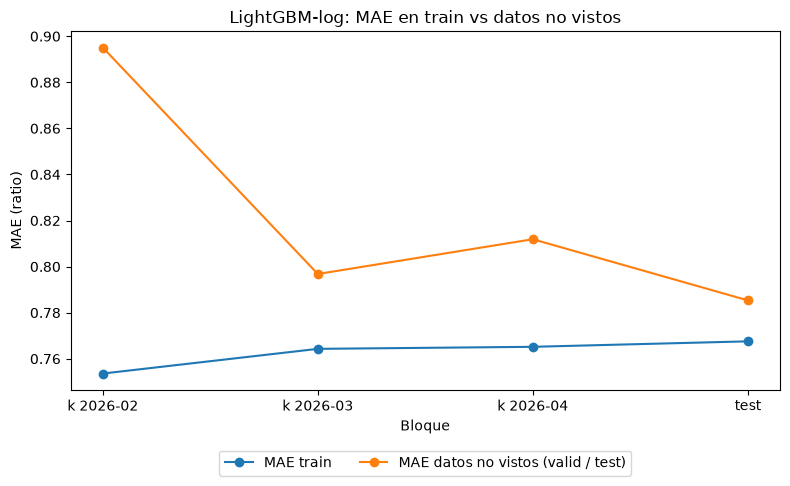

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sobreajuste["bloque"], sobreajuste["MAE_train"], marker="o", label="MAE train")
ax.plot(sobreajuste["bloque"], sobreajuste["MAE_eval"],  marker="o", label="MAE datos no vistos (valid / test)")
ax.set_title("LightGBM-log: MAE en train vs datos no vistos")
ax.set_xlabel("Bloque")
ax.set_ylabel("MAE (ratio)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

Me interesa graficar la evolución del error mes a mes, para el conjunto total de los datos:

In [44]:
# Modelo final: entrenado con todo desarrollo (el mismo que se evaluó en test)
desarrollo = df[df["split"] == "desarrollo"]
modelo_LGBM_log.fit(desarrollo[X_COLS], np.log(desarrollo[OBJETIVO]))

# Error fase a fase en todos los meses
evolucion = df[["mes_orden", OBJETIVO]].copy()
evolucion["pred"]       = np.exp(modelo_LGBM_log.predict(df[X_COLS]))
evolucion["err_modelo"] = (evolucion["pred"] - evolucion[OBJETIVO]).abs()
evolucion["err_B0"]     = (1 - evolucion[OBJETIVO]).abs()

# MAE por mes = media del error absoluto de las fases de ese mes
mae_mensual = evolucion.groupby("mes_orden")[["err_modelo", "err_B0"]].mean()
display(mae_mensual.round(3))

fila_min = mae_mensual.loc[mae_mensual['err_modelo'].idxmin()]
fila_max = mae_mensual.loc[mae_mensual['err_modelo'].idxmax()]

print(f"Error mínimo: {fila_min['err_B0']:.3f} (mes: {fila_min.name})")
print(f"Error máximo: {fila_max['err_modelo']:.3f} (mes: {fila_max.name})")

,err_modelo,err_B0
mes_orden,,
2025-06,0.748,0.985
2025-07,0.744,0.944
2025-08,0.676,0.842
2025-09,0.718,0.919
2025-10,0.736,0.997
2025-11,0.795,1.076
2025-12,0.885,1.202
2026-01,0.853,1.131
2026-02,0.820,1.144


Error mínimo: 0.842 (mes: 2025-08)
Error máximo: 0.885 (mes: 2025-12)


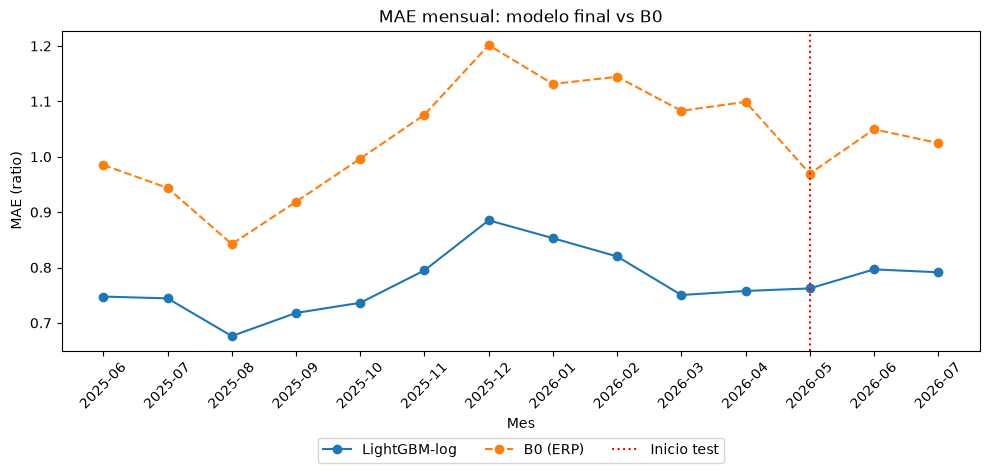

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mae_mensual.index, mae_mensual["err_modelo"], marker="o", label="LightGBM-log")
ax.plot(mae_mensual.index, mae_mensual["err_B0"],     marker="o", linestyle="--", label="B0 (ERP)")
ax.axvline("2026-05", color="red", linestyle=":", label="Inicio test")

ax.set_title("MAE mensual: modelo final vs B0")
ax.set_xlabel("Mes")
ax.set_ylabel("MAE (ratio)")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3)
plt.tight_layout()
plt.show()

Este gráfico muestra tres cosas interesantes:

- El modelo tiene menos error que B0 en los 14 meses.
- La línea de B0 (naranja) marca los meses más difíciles de predecir, en los que el tiempo real se aleja más del tiempo previsto por el ERP. El tramo de noviembre a febrero es el más difícil, con el máximo en diciembre, y agosto el más fácil. El modelo sube y baja en los mismos meses que B0, lo que indica que la variación mensual de su error se debe sobre todo a la dificultad de cada mes y no a un comportamiento distinto del modelo.
- La línea roja marca el corte entre entrenamiento y test. En los meses de test el MAE del modelo (0.762–0.797) queda dentro del rango de los meses de entrenamiento (0.676–0.885) y muy cerca de los últimos meses de desarrollo. Que el error apenas suba al pasar a datos no vistos es un buen indicador de generalización.

### SHAP

In [45]:
!pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   -- ------------------------------------- 2.4/41.9 MB 11.4 MB/s eta 0:00:04
   --- ------------------------------------ 3.4/41.9 MB 8.0 MB/s eta 0:00:05
   ----- ---------------------------------- 5.5/41.9 MB 8.6 MB/s eta 0:00:05
   -------- ------------------------------- 8.4/41.9 MB 9.7 MB/s eta 0:00:04
   --------- ------------------------------ 10.0/41.9 MB 9.4 MB/s eta 0:00:04
   ----------- ---------------------------- 11.5/41.9 MB 9.2 MB/s eta 0:00:04
   ----------- ---------------------------- 12.3/41.9 MB 8.3 MB/s eta 0:00:04
   ------------- -------------------------- 14.4/41.9 MB 8.7 MB/s eta 0:00:04
   --------------- ------------------------ 16.0/41.9 MB 8.5 MB/s eta 0:00:04
   ------------------ --------------------- 19.1/41.9 MB 9.1 MB/s eta 0:00:03
   --------------------- ------------------ 22.0/41.9 MB 9.6 MB/s eta 0:00:03
   ----------------------- ---------------- 24.9/41.9 MB 9.9 MB/s eta 0:00:

In [49]:
import shap

# Modelo final: LightGBM-log entrenado con todo desarrollo
desarrollo = df[df["split"] == "desarrollo"]
test       = df[df["split"] == "test"]
modelo_LGBM_log.fit(desarrollo[X_COLS], np.log(desarrollo[OBJETIVO]))

# Explicador para modelos de árboles
explainer = shap.TreeExplainer(modelo_LGBM_log)
shap_values = explainer(test[X_COLS])

print(shap_values.shape)          # (fases de test, nº variables)
print(explainer.expected_value.round(3))          # valor base en log
print(F"Predicción media: {np.exp(explainer.expected_value).round(3)}")  # valor base en ratio

(2396, 7)
0.42
Predicción media: 1.523


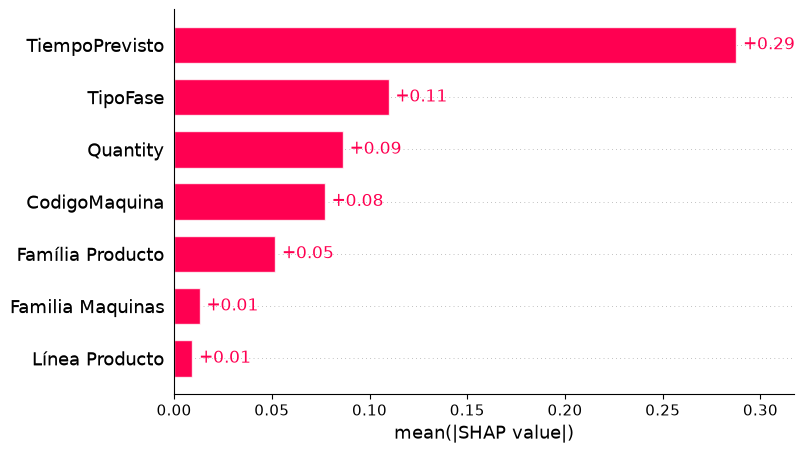

In [51]:
shap.plots.bar(shap_values)

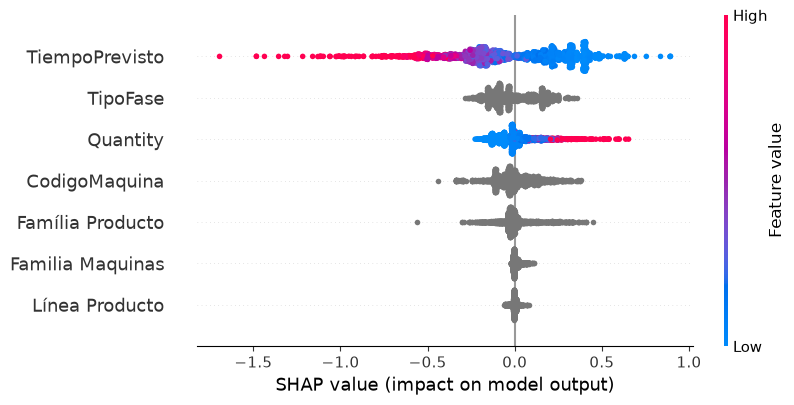

In [52]:
shap.plots.beeswarm(shap_values)

In [53]:
importancia = pd.Series(np.abs(shap_values.values).mean(axis=0), index=X_COLS)
display(pd.DataFrame({"media_abs_SHAP": importancia,
                      "efecto_ratio_%": (np.exp(importancia) - 1) * 100})
        .sort_values("media_abs_SHAP", ascending=False).round(2))

,media_abs_SHAP,efecto_ratio_%
TiempoPrevisto,0.29,33.34
TipoFase,0.11,11.61
Quantity,0.09,9.03
CodigoMaquina,0.08,8.03
Família Producto,0.05,5.32
Familia Maquinas,0.01,1.33
Línea Producto,0.01,0.95


##### Interpretabilidad del modelo final (SHAP en test)

**Importancia global:**   
`TiempoPrevisto` obtiene el valor más alto (0.29), seguido de `TipoFase` (0.11), `Quantity` (0.09) y `CodigoMaquina` (0.08). `Família Producto` obtiene 0.05, y `Familia Maquinas` y `Línea Producto` 0.01.

**Dirección del efecto:**    
- `TiempoPrevisto`: los valores bajos se asocian a valores SHAP positivos (aumentan el ratio inferido) y los valores altos a valores SHAP negativos (lo reducen).
- `Quantity`: los valores altos se asocian a valores SHAP positivos.
- `TipoFase`, `CodigoMaquina` y `Família Producto` presentan valores SHAP positivos y negativos.
- `Familia Maquinas` y `Línea Producto` presentan valores SHAP concentrados en torno a 0. La baja influencia de estas variables se explica por la estructura jerárquica de las mismas: cada máquina pertenece a una única familia y cada familia de producto a una única línea. Al conocer `CodigoMaquina` y `Família Producto`, el modelo dispone ya de la información de `Familia Maquinas` y `Línea Producto`, por lo que estas no aportan información adicional. Esto no implica que la familia de máquina o la línea de producto no estén relacionadas con la desviación, sino que su efecto queda recogido a través de las variables más detalladas.